In [30]:
import numpy as np
import pandas as pd
from ethos_tised import SolarModel
import pathlib

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
from scipy.stats import ks_2samp
from sklearn.metrics import root_mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [18]:
current_dir = pathlib.Path.cwd().parent
path_to_hourly_data = current_dir.joinpath(
    "Examples", "hourly_data", "Berlin.csv")

hourly_irrad_m = np.genfromtxt(
    path_to_hourly_data,
    delimiter=",",
)

In [19]:
synthetic = SolarModel(Lat=52.455778, Lon=13.523917, date=2018, data=hourly_irrad_m)

Structured hourly data shape: (8760, 3)
The provided hourly GHI data has no missing values. Proceeding with original data.
Timezone: Europe/Berlin
Start: 2018-01-01 00:00:00+01:00
End: 2018-12-31 23:59:00+01:00
Detected Köppen-Geiger Zone: Cfb
Mapped Climate Zone: Cfb
                 day  synthetic_ghi
count  525600.000000  525600.000000
mean      183.000000     137.460745
std       105.366129     229.251564
min         1.000000       0.000000
25%        92.000000       0.000000
50%       183.000000       0.000000
75%       274.000000     185.035931
max       365.000000    1218.566709


In [20]:
path_to_measured_data = current_dir /'Examples'/'Results'/'Berlin'/'Berlin2018.csv'

data = pd.read_csv(path_to_measured_data)
data

,Unnamed: 0,ghi
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
525595,525595,0
525596,525596,0
525597,525597,0
525598,525598,0


In [ ]:
rms = root_mean_squared_error(data["ghi"], synthetic["synthetic_ghi"])
nrmse = round(rms / (data["ghi"].max() - data["ghi"].min()) * 100, 2)
print("###############################################################################")
print("Synthetic GHI")
print("###############################################################################")
print("Minute RMSE is:", round(rms, 2))
print("Minute NRMSE is:", nrmse, "%")

###############################################################################
Synthetic GHI
###############################################################################
RMSE is: 101.39
NRMSE is: 8.32 %


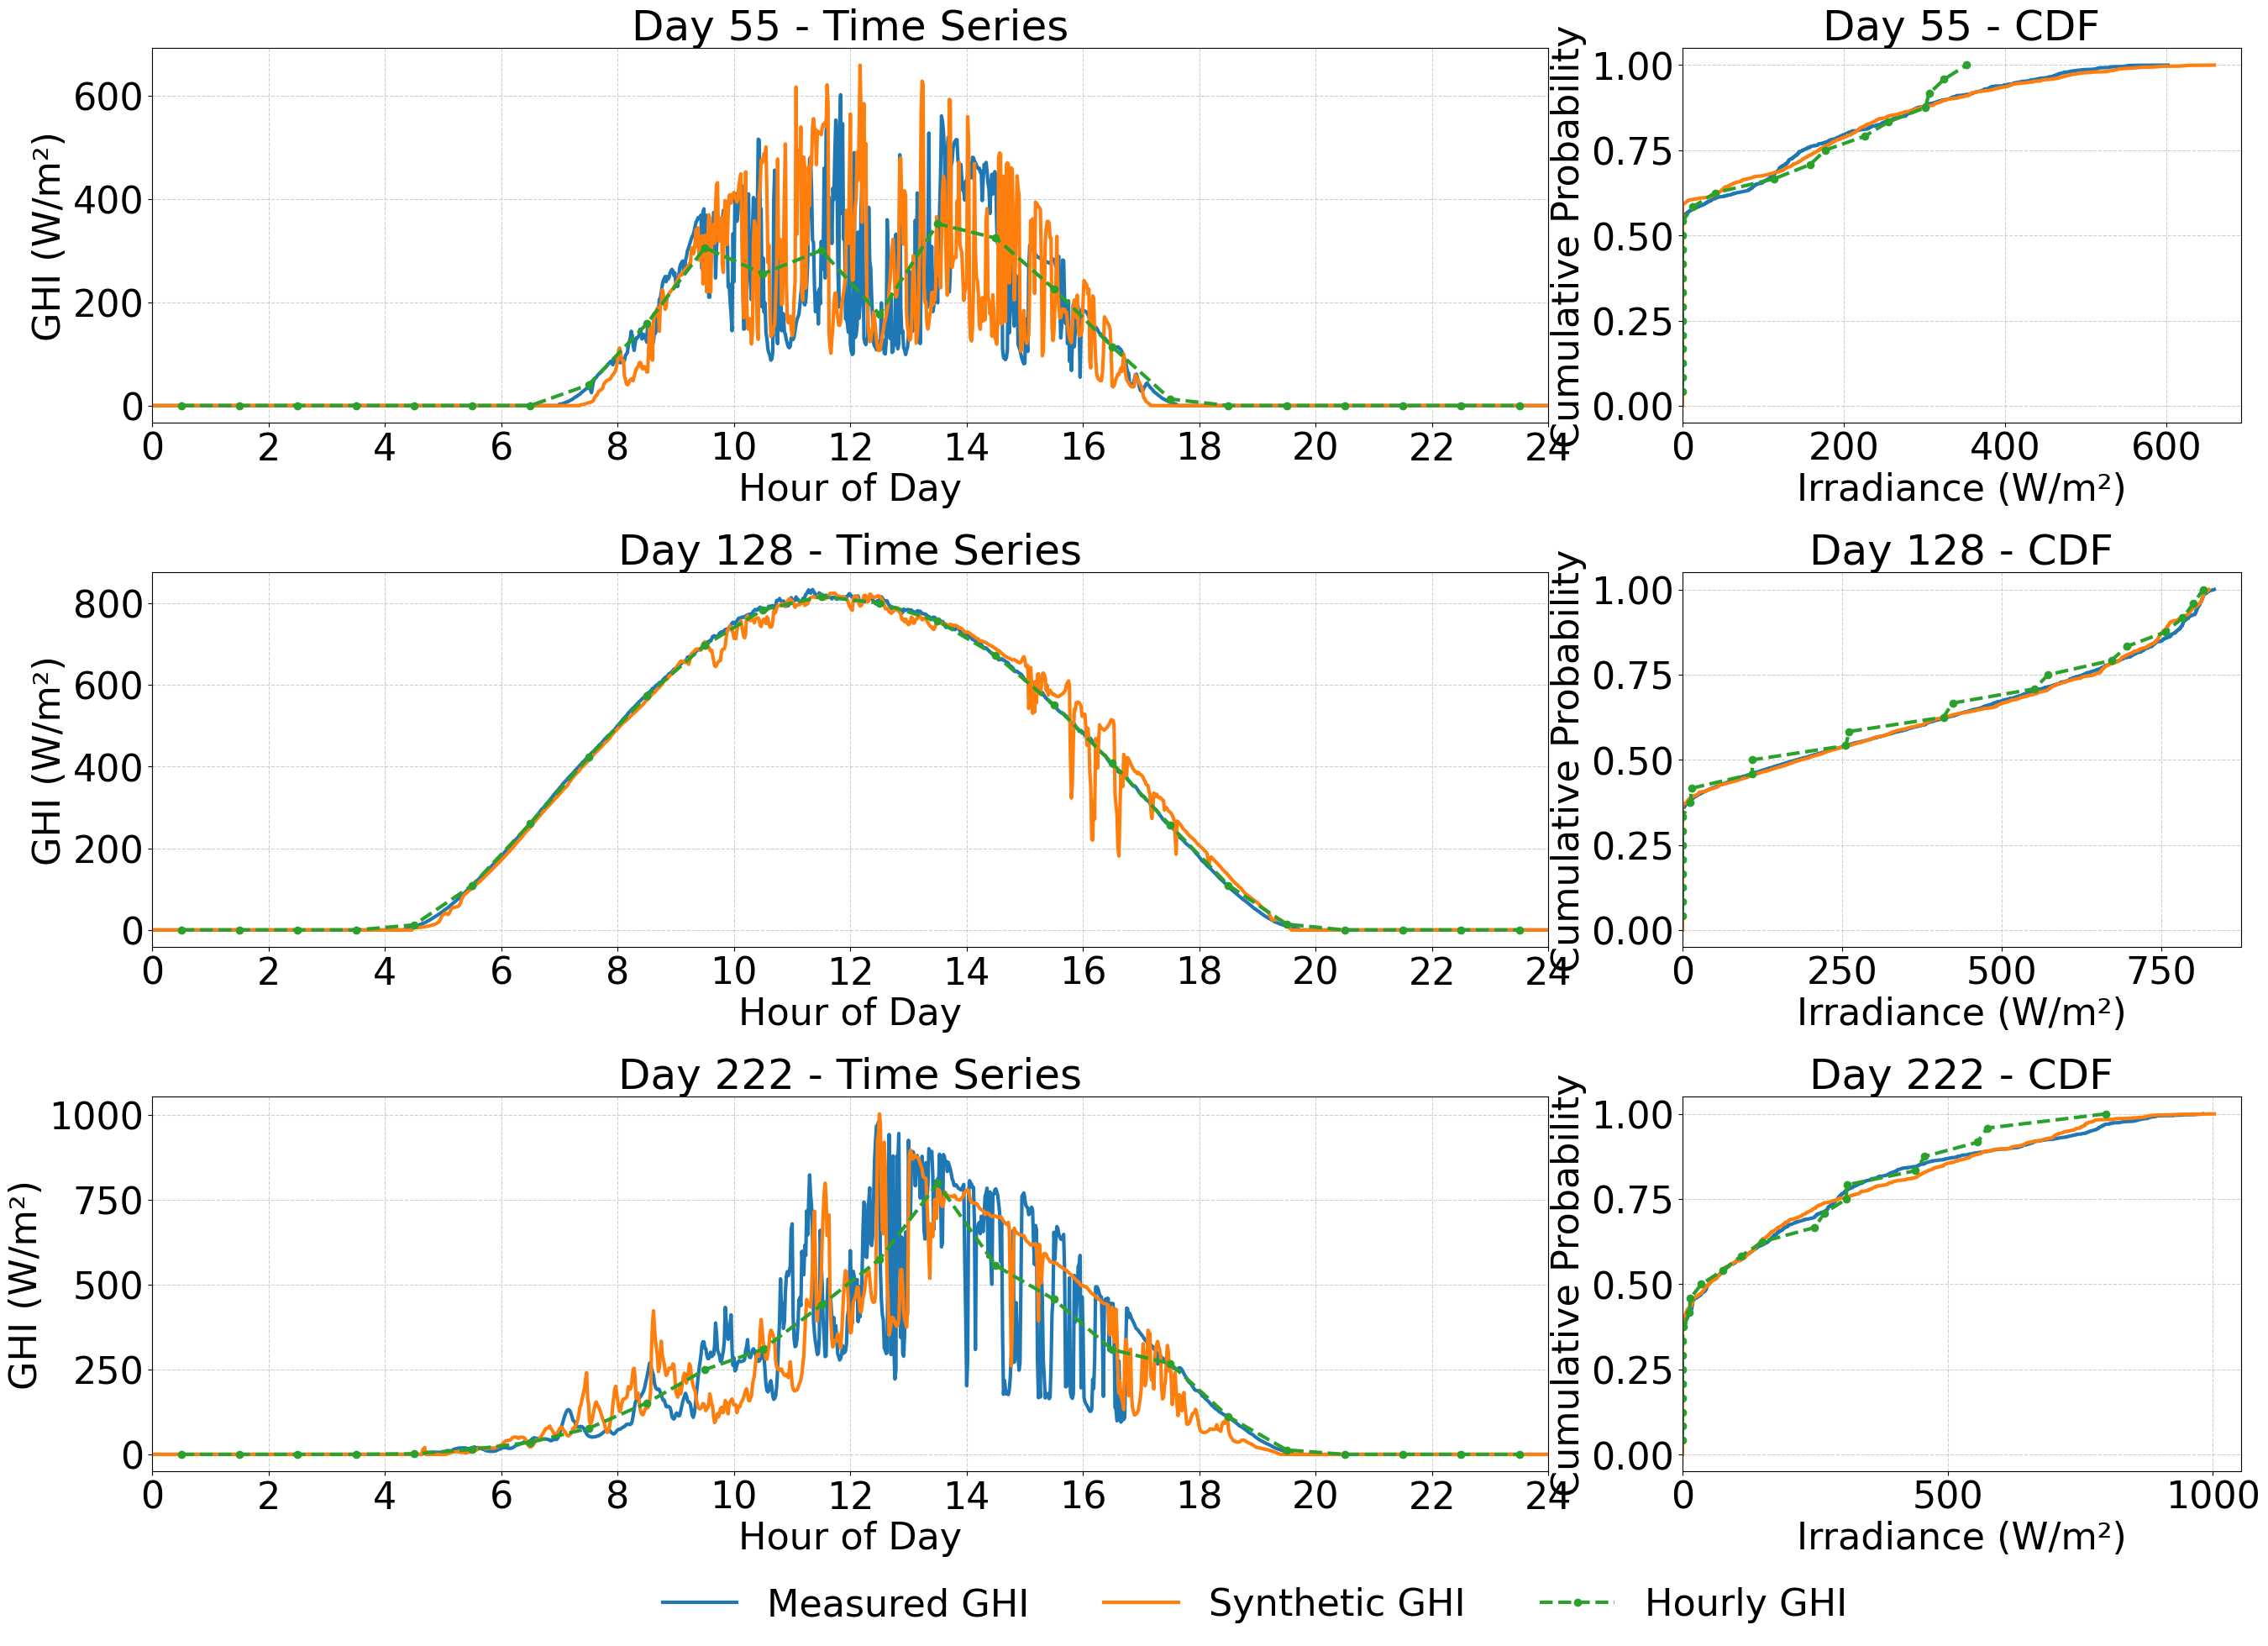

In [50]:
# Parameters
noOfdays = 365
minutes_per_day = 1440
hours_per_day = 24

days_to_plot = [54, 127, 221]  # zero-based indexing

fontsize = 36
fontsize1 = 32
fontsize2 = 32
linewidth = 3


# Extract and reshape data
ghi_measured = data['ghi'].values
ghi_synthetic = synthetic['synthetic_ghi'].values
ghi_hourly = hourly_irrad_m

ghi_measured_reshaped = ghi_measured.reshape(noOfdays, minutes_per_day)
ghi_synthetic_reshaped = ghi_synthetic.reshape(noOfdays, minutes_per_day)
ghi_hourly_reshaped = ghi_hourly.reshape(noOfdays, hours_per_day)


# Time axes (hours)
minutes_axis = np.arange(minutes_per_day)
hours_axis_minute = minutes_axis / 60.0          # 0 → 24 (minute resolution)
hours_axis_hourly = np.arange(1/2, hours_per_day + 1/2)  # 1 → 24 (hourly data)


# CDF function
def calculate_cdf(data):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf


# Figure layout
fig = plt.figure(figsize=(35, 22))
gs = GridSpec(len(days_to_plot), 3, width_ratios=[2.5, 1, 0.1], hspace=0.4)


# Plotting loop
for i, day in enumerate(days_to_plot):

    # ---- Time series plot (hours)
    ax_line = fig.add_subplot(gs[i, 0])

    ax_line.plot(
        hours_axis_minute,
        ghi_measured_reshaped[day],
        label='Measured GHI',
        linewidth=linewidth
    )

    ax_line.plot(
        hours_axis_minute,
        ghi_synthetic_reshaped[day],
        label='Synthetic GHI',
        linewidth=linewidth
    )

    ax_line.plot(
        hours_axis_hourly,
        ghi_hourly_reshaped[day],
        label='Hourly GHI',
        linestyle='--',
        marker='o',
        linewidth=linewidth
    )

    ax_line.set_xlim(0, 24)
    ax_line.set_xticks(np.arange(0, 25, 2))
    ax_line.set_title(f'Day {day + 1} - Time Series', fontsize=fontsize)
    ax_line.set_xlabel('Hour of Day', fontsize=fontsize2)
    ax_line.set_ylabel('GHI (W/m²)', fontsize=fontsize2)
    ax_line.tick_params(axis='both', which='major', labelsize=fontsize1)
    ax_line.grid(True, linestyle='--', alpha=0.6)

    # ---- CDF plot (minute + hourly)
    ax_cdf = fig.add_subplot(gs[i, 1])

    measured_sorted, measured_cdf = calculate_cdf(ghi_measured_reshaped[day])
    synthetic_sorted, synthetic_cdf = calculate_cdf(ghi_synthetic_reshaped[day])
    hourly_sorted, hourly_cdf = calculate_cdf(ghi_hourly_reshaped[day])

    ax_cdf.plot(
        measured_sorted,
        measured_cdf,
        linewidth=linewidth,
        label='Measured GHI'
    )

    ax_cdf.plot(
        synthetic_sorted,
        synthetic_cdf,
        linewidth=linewidth,
        label='Synthetic GHI'
    )

    ax_cdf.plot(
        hourly_sorted,
        hourly_cdf,
        linestyle='--',
        marker='o',
        linewidth=linewidth,
        label='Hourly GHI'
    )

    ax_cdf.set_xlim(0, None)
    ax_cdf.set_title(f'Day {day + 1} - CDF', fontsize=fontsize)
    ax_cdf.set_xlabel('Irradiance (W/m²)', fontsize=fontsize2)
    ax_cdf.set_ylabel('Cumulative Probability', fontsize=fontsize2)
    ax_cdf.tick_params(axis='both', which='major', labelsize=fontsize1)
    ax_cdf.grid(True, linestyle='--', alpha=0.6)

# Legend
fig.legend(
    ['Measured GHI', 'Synthetic GHI', 'Hourly GHI'],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    fontsize=fontsize1,
    frameon=False
)

#plt.show()
plt.savefig('ghi_minute_hourly_cdf.png', bbox_inches='tight', dpi=300)


C:\Users\o.omoyele\AppData\Local\Temp\ipykernel_23888\4292388245.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


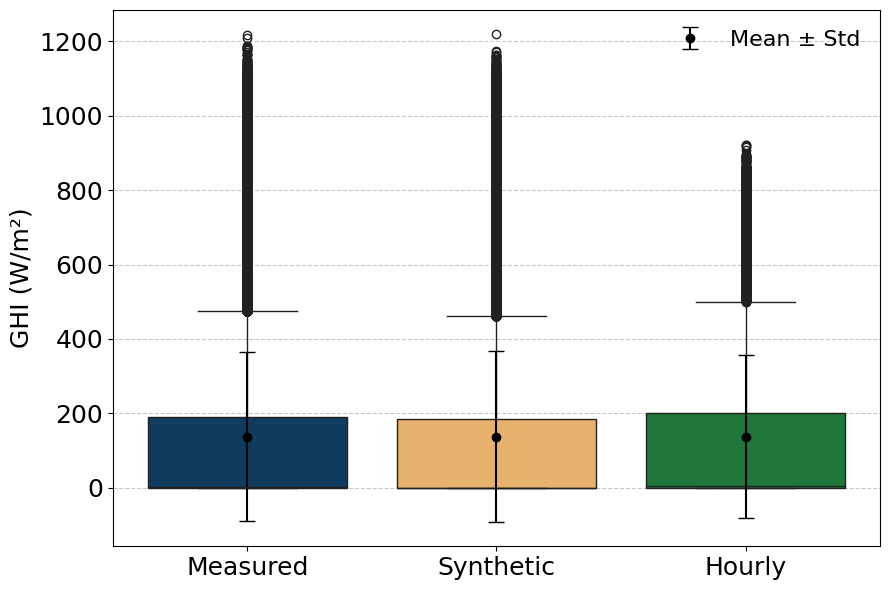

In [53]:
# Build long-format DataFrame
df_melted = pd.concat([
    pd.DataFrame({
        'Type': 'Measured',
        'GHI Value': data['ghi'].dropna().values
    }),
    pd.DataFrame({
        'Type': 'Synthetic',
        'GHI Value': synthetic['synthetic_ghi'].dropna().values
    }),
    pd.DataFrame({
        'Type': 'Hourly',
        'GHI Value': hourly_irrad_m
    })
], ignore_index=True)


# Compute means and stds
stats = df_melted.groupby('Type')['GHI Value'].agg(['mean', 'std']).reset_index()


# Plot settings
palette = {
    'Measured': '#023d6b',
    'Synthetic': '#fab45a',
    'Hourly': "#118435"
}

order = ['Measured', 'Synthetic', 'Hourly']


# Plot boxplot
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_melted,
    x='Type',
    y='GHI Value',
    palette=palette,
    order=order
)


# Mean ± std
for _, row in stats.iterrows():
    x = order.index(row['Type'])
    plt.errorbar(
        x,
        row['mean'],
        yerr=row['std'],
        fmt='o',
        color='black',
        capsize=6,
        label='Mean ± Std' if row['Type'] == 'Measured' else ""
    )


# Formatting
plt.ylabel('GHI (W/m²)', fontsize=18)
plt.xlabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=16, frameon=False)

plt.tight_layout()
#plt.show()
plt.savefig('Box_plot_with_hourly.png', dpi=300, bbox_inches='tight')